# **Notebook 4.3: 6G Intelligent Beamforming with QML**

**Objective:** This notebook introduces Quantum Machine Learning (QML) by applying a **Quantum Support Vector Classifier (QSVC)** to a simulated **intelligent beamforming** problem. 

We will:
1.  Build a simple 2D model to visualize how QSVC works.
2.  Perform hyperparameter tuning to find the best model complexity.
3.  Run a scalability experiment to compare the **performance (time and accuracy)** of a classical `SVC` vs. a simulated `QSVC` as the problem complexity (number of users/features) grows.

### **1. The Telecom Problem: Intelligent Beamforming**

In 6G networks, base stations use beamforming to precisely direct radio signals to users. The optimal beam configuration (e.g., its angle and width) depends on complex factors like user location, obstacles, and signal reflections. This can be framed as a **classification problem**: based on input data (like user coordinates and channel state information), the system must choose the best beam configuration from a predefined set.

We will simulate a scenario where our features are **User Azimuth** (horizontal angle) and **Signal Strength**, and our classes are the different beams to assign.

---

### **2. Setup: Importing Libraries**

In [1]:
# Core Python libraries
import numpy as np
import matplotlib.pyplot as plt
import time

# Scikit-learn for classical ML and data generation
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Qiskit imports
from qiskit.circuit.library import ZZFeatureMap
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit.primitives import StatevectorSampler # <-- V2 SAMPLER

# Set a seed for reproducibility
np.random.seed(42)

---

### **3. Generating a Synthetic 2D Dataset**

First, we create a simple 2-feature dataset to visualize the problem. This is our 'toy problem'.

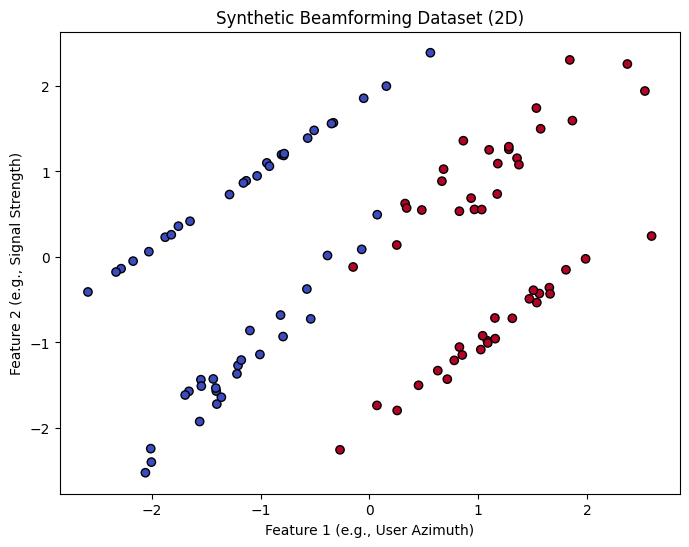

In [2]:
# Generate a dataset with 2 features for easy visualization
X_2d, y_2d = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=2
)

# Split the data into training and testing sets
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.3, random_state=42)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("Synthetic Beamforming Dataset (2D)")
plt.xlabel("Feature 1 (e.g., User Azimuth)")
plt.ylabel("Feature 2 (e.g., Signal Strength)")
plt.show()

---

### **4. Classical Benchmark (on 2D data)**

Let's train a classical SVM with a Radial Basis Function (RBF) kernel. This is the classical equivalent of the quantum kernel.

In [3]:
# Create and train the classical SVM
classical_svm = SVC(kernel='rbf')
classical_svm.fit(X_train_2d, y_train_2d)

# Make predictions
classical_preds = classical_svm.predict(X_test_2d)
classical_accuracy = accuracy_score(y_test_2d, classical_preds)

print(f"Classical SVM (2D) Accuracy: {classical_accuracy * 100:.2f}%")

Classical SVM (2D) Accuracy: 100.00%


---

### **5. Quantum Approach: Hyperparameter Tuning (on 2D data)**

Now we'll use the QSVC. We will tune the `reps` hyperparameter in our `ZZFeatureMap` to find the best model complexity.

--- Testing with reps = 1 ---
Accuracy for reps = 1: 80.00%
--- Testing with reps = 2 ---
Accuracy for reps = 2: 60.00%
--- Testing with reps = 3 ---
Accuracy for reps = 3: 60.00%
--- Testing with reps = 4 ---
Accuracy for reps = 4: 53.33%
--- Testing with reps = 5 ---
Accuracy for reps = 5: 50.00%


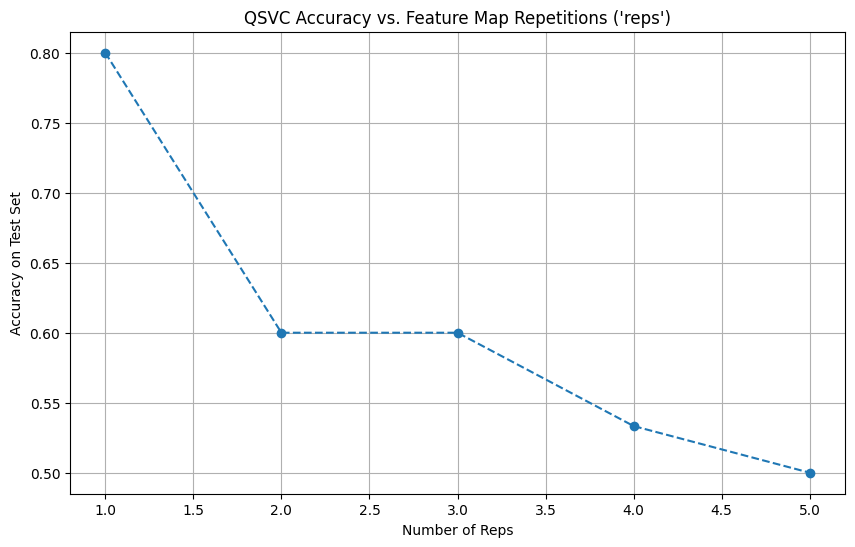


Best result found with reps = 1, achieving an accuracy of 80.00%.

Re-training the best model with reps = 1 for visualization...
Best 2D model is ready for plotting.


In [4]:
accuracies_2d = {}
reps_to_test = [1, 2, 3, 4, 5] # Test a range of complexity values

# 2. Define the Sampler and Fidelity object (V2)
#    We define this ONCE outside the loop for efficiency.
sampler = StatevectorSampler()  # <-- FIX: Instantiate the V2 Sampler
fidelity = ComputeUncompute(sampler=sampler)

for reps_val in reps_to_test:
    print(f"--- Testing with reps = {reps_val} ---")
    
    # 1. Define the Feature Map
    num_features = X_2d.shape[1]
    feature_map = ZZFeatureMap(feature_dimension=num_features, reps=reps_val)

    # 3. Instantiate the Quantum Kernel
    quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

    # 4. Instantiate and Train the QSVC
    qsvc = QSVC(quantum_kernel=quantum_kernel)
    qsvc.fit(X_train_2d, y_train_2d)

    # 5. Make predictions and store accuracy
    qsvc_preds = qsvc.predict(X_test_2d)
    accuracies_2d[reps_val] = accuracy_score(y_test_2d, qsvc_preds)
    print(f"Accuracy for reps = {reps_val}: {accuracies_2d[reps_val] * 100:.2f}%")

# --- Plot the tuning results ---
plt.figure(figsize=(10, 6))
plt.plot(list(accuracies_2d.keys()), list(accuracies_2d.values()), marker='o', linestyle='--')
plt.title("QSVC Accuracy vs. Feature Map Repetitions ('reps')")
plt.xlabel("Number of Reps")
plt.ylabel("Accuracy on Test Set")
plt.grid(True)
plt.show()

# --- Find the best result and re-train the model for visualization ---
best_reps = max(accuracies_2d, key=accuracies_2d.get)
best_accuracy = accuracies_2d[best_reps]
print(f"\nBest result found with reps = {best_reps}, achieving an accuracy of {best_accuracy * 100:.2f}%.")

print(f"\nRe-training the best model with reps = {best_reps} for visualization...")
best_feature_map = ZZFeatureMap(feature_dimension=num_features, reps=best_reps)
best_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=best_feature_map)

qsvc_best = QSVC(quantum_kernel=best_kernel)
qsvc_best.fit(X_train_2d, y_train_2d)
qsvc_best_preds = qsvc_best.predict(X_test_2d) # Create predictions for the next cell

print("Best 2D model is ready for plotting.")

---

### **6. Visualizing the Best 2D Model's Predictions**

Now we plot the test data and highlight any points that the best QSVC model misclassified.

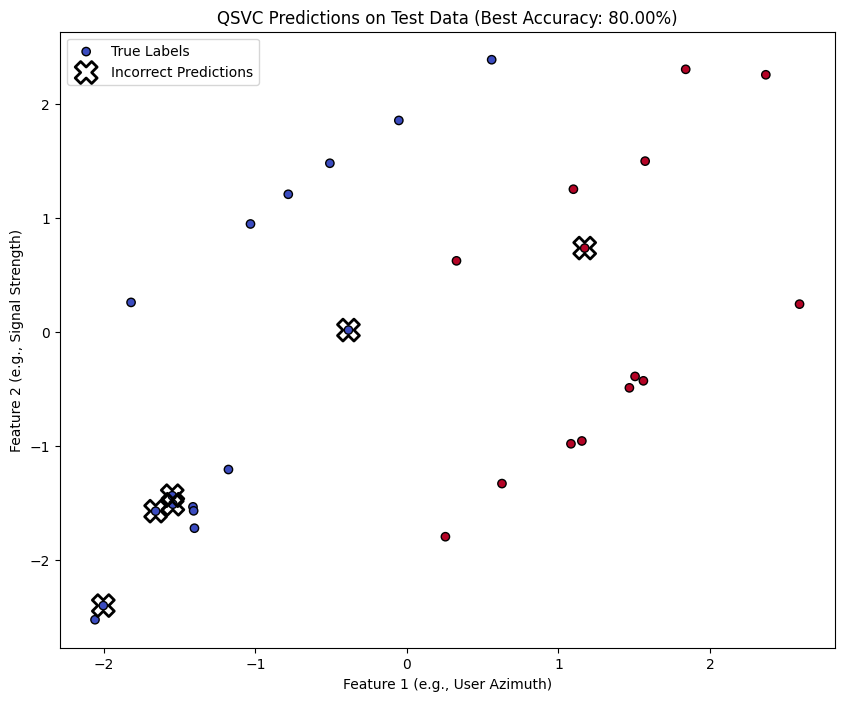

In [5]:
plt.figure(figsize=(10, 8))

# Plot the test data points, colored by their true label
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_2d, cmap=plt.cm.coolwarm, edgecolors='k', label='True Labels')

# Find where the QSVC made incorrect predictions
incorrect_indices = np.where(y_test_2d != qsvc_best_preds)[0]

# Highlight the incorrect predictions with large 'X' markers
plt.scatter(
    X_test_2d[incorrect_indices, 0],
    X_test_2d[incorrect_indices, 1],
    s=250,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    marker='X',
    label='Incorrect Predictions'
)

plt.title(f'QSVC Predictions on Test Data (Best Accuracy: {best_accuracy*100:.2f}%)')
plt.xlabel('Feature 1 (e.g., User Azimuth)')
plt.ylabel('Feature 2 (e.g., Signal Strength)')
plt.legend()
plt.show()

---

### **7. Scalability Experiment: QML vs. Classical**

The 2D problem was just a warm-up. The *real* telecom problem involves many features (e.g., data from many users, or complex channel information).

Here, we will simulate a more complex problem by increasing the number of users. We'll assume **2 features per user** (Azimuth, Signal Strength). 

* **2 Users = 4 Features**
* **4 Users = 8 Features**
* **8 Users = 16 Features**
* **16 Users = 32 Features**

We will test both the **Classical SVM** and the **Simulated QSVC** to see how their **training time** and **accuracy** scale with the number of features (qubits).

#### **7.1 Classical SVM Scalability**

First, let's run the classical `SVC`. We expect this to be very fast and scale well.

🚀 Starting Classical Scalability Experiment...

STARTING TEST: 2 Users (4 Features)
Generating 150 samples with 4 features...
Tuning 'C' parameter for 2 users...
--- Testing C = 0.1... Accuracy: 84.44% (Time: 0.0016s)
--- Testing C = 1.0... Accuracy: 93.33% (Time: 0.0015s)
--- Testing C = 10.0... Accuracy: 93.33% (Time: 0.0017s)
--- BEST for 2 users: 93.33% (found at C=1.0) ---
--- Total time for 2 users: 0.0100s ---

STARTING TEST: 4 Users (8 Features)
Generating 150 samples with 8 features...
Tuning 'C' parameter for 4 users...
--- Testing C = 0.1... Accuracy: 42.22% (Time: 0.0017s)
--- Testing C = 1.0... Accuracy: 88.89% (Time: 0.0014s)
--- Testing C = 10.0... Accuracy: 86.67% (Time: 0.0019s)
--- BEST for 4 users: 88.89% (found at C=1.0) ---
--- Total time for 4 users: 0.0082s ---

STARTING TEST: 8 Users (16 Features)
Generating 150 samples with 16 features...
Tuning 'C' parameter for 8 users...
--- Testing C = 0.1... Accuracy: 46.67% (Time: 0.0026s)
--- Testing C = 1.0... Accuracy:

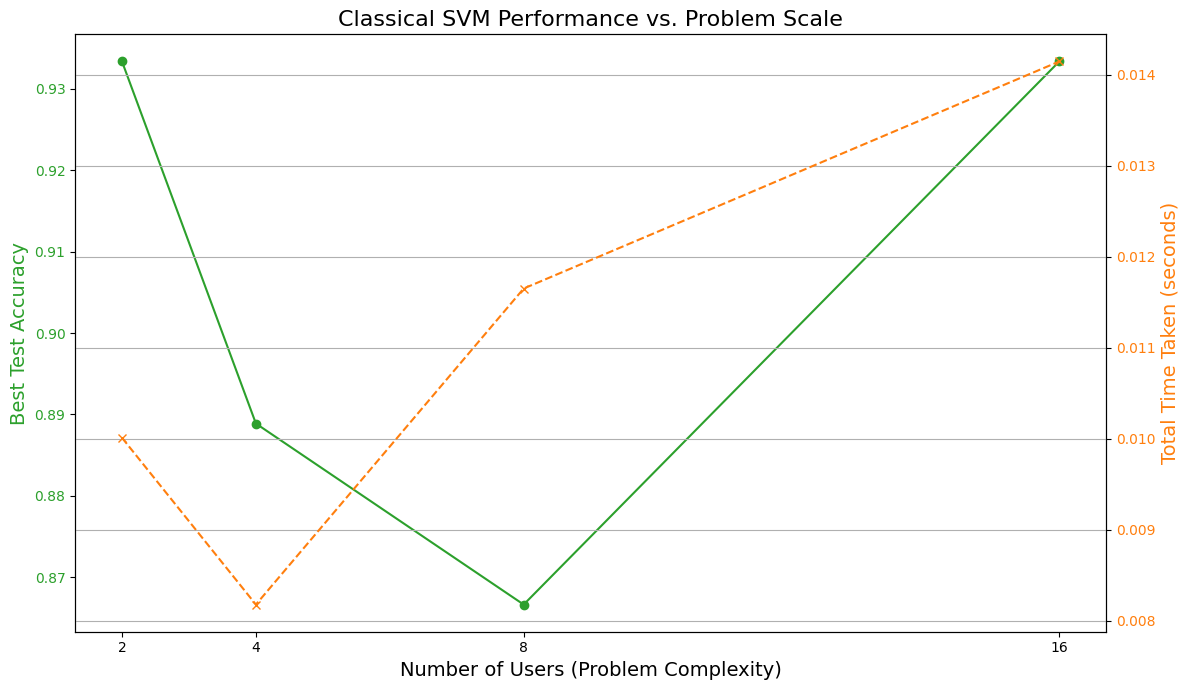

In [6]:
# --- CONFIGURATION --- 
users_to_test_classical = [2, 4, 8, 16] # Classical can easily handle 16 users (32 features)
params_to_test = [0.1, 1.0, 10.0]  # Tune 'C' parameter (SVM's complexity knob)
n_samples = 150

# --- STORAGE --- 
classical_results = {
    "users": [],
    "best_accuracy": [],
    "time_taken": []
}

# --- 1. MAIN EXPERIMENT LOOP --- 
print("🚀 Starting Classical Scalability Experiment...")

for n_users in users_to_test_classical:
    num_features = n_users * 2
    print(f"\n========================================================")
    print(f"STARTING TEST: {n_users} Users ({num_features} Features)")
    print(f"========================================================")
    
    exp_start_time = time.time()
    
    # --- 2. Generate Dataset ---
    print(f"Generating {n_samples} samples with {num_features} features...")
    X, y = make_classification(
        n_samples=n_samples,
        n_features=num_features,
        n_informative=num_features,
        n_redundant=0,
        random_state=42,
        n_clusters_per_class=2
    )
    
    # Scale data: SVMs are sensitive to feature scales
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # --- 3. Inner Loop: Hyperparameter Tuning (C parameter) ---
    accuracies = {}
    print(f"Tuning 'C' parameter for {n_users} users...")
    
    for c_val in params_to_test:
        print(f"--- Testing C = {c_val}...", end='', flush=True)
        rep_start_time = time.time()
        
        # 1. Define Model (using RBF kernel)
        classical_svm = SVC(kernel='rbf', C=c_val)
        
        # 2. Train
        classical_svm.fit(X_train, y_train)
        
        # 3. Predict & Score
        class_preds = classical_svm.predict(X_test)
        acc = accuracy_score(y_test, class_preds)
        accuracies[c_val] = acc
        
        rep_time = time.time() - rep_start_time
        print(f" Accuracy: {acc*100:.2f}% (Time: {rep_time:.4f}s)")

    # --- 4. Store Best Result ---
    best_c = max(accuracies, key=accuracies.get)
    best_accuracy = accuracies[best_c]
    total_time = time.time() - exp_start_time
    
    print(f"--- BEST for {n_users} users: {best_accuracy*100:.2f}% (found at C={best_c}) ---")
    print(f"--- Total time for {n_users} users: {total_time:.4f}s ---")
    
    classical_results["users"].append(n_users)
    classical_results["best_accuracy"].append(best_accuracy)
    classical_results["time_taken"].append(total_time)

print("\n========================================================")
print("✅ Classical Experiment Complete. Plotting final results...")
print("========================================================")

# --- 5. FINAL PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Accuracy
color = 'tab:green'
ax1.set_xlabel("Number of Users (Problem Complexity)", fontsize=14)
ax1.set_ylabel("Best Test Accuracy", color=color, fontsize=14)
ax1.plot(classical_results["users"], classical_results["best_accuracy"], marker='o', linestyle='-', color=color, label='Classical SVM Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(classical_results["users"])

# Create a second y-axis for time
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel("Total Time Taken (seconds)", color=color, fontsize=14)
ax2.plot(classical_results["users"], classical_results["time_taken"], marker='x', linestyle='--', color=color, label='Classical SVM Time')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Classical SVM Performance vs. Problem Scale", fontsize=16)
fig.tight_layout()
plt.grid(True)
plt.show()

#### **7.2 Quantum SVM (QSVC) Scalability**

Now, we run the same experiment with the `QSVC`. 

⚠️ **WARNING:** This cell will take a **very long time** to run. We are *simulating* a quantum computer, which is exponentially slow. The 4-user (8-qubit) test will take minutes, and the 8-user (16-qubit) test could take **hours** or crash your kernel. This bottleneck is the *entire point* of the experiment.

In [ ]:
# --- CONFIGURATION --- 
users_to_test_quantum = [2, 4, 8]  # 8 users (16 qubits) is already a massive simulation
reps_to_test = [1, 2, 3]    # Keep reps small to save time
n_samples = 150

# --- V2 SAMPLER (Define ONCE) ---
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

# --- STORAGE ---
quantum_results = {
    "users": [],
    "best_accuracy": [],
    "time_taken": []
}

# --- 1. MAIN EXPERIMENT LOOP ---
print("🚀 Starting Quantum (QSVC) Scalability Experiment...")

for n_users in users_to_test_quantum:
    num_features = n_users * 2
    print(f"\n========================================================")
    print(f"STARTING TEST: {n_users} Users ({num_features} Features/Qubits)")
    print(f"========================================================")
    
    exp_start_time = time.time()
    
    # --- 2. Generate Dataset ---
    print(f"Generating {n_samples} samples with {num_features} features...")
    X, y = make_classification(
        n_samples=n_samples,
        n_features=num_features,
        n_informative=num_features, 
        n_redundant=0,
        random_state=42,
        n_clusters_per_class=2
    )
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # --- 3. Inner Loop: Hyperparameter Tuning ('reps') ---
    accuracies = {}
    print(f"Tuning 'reps' parameter for {n_users} users...")
    
    for reps_val in reps_to_test:
        print(f"--- Testing reps = {reps_val}...", end='', flush=True)
        rep_start_time = time.time()
        
        try:
            # 1. Define Feature Map
            feature_map = ZZFeatureMap(feature_dimension=num_features, reps=reps_val)
            
            # 2. Define Kernel (reuses fidelity)
            quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)
            
            # 3. Train QSVC
            qsvc = QSVC(quantum_kernel=quantum_kernel)
            qsvc.fit(X_train, y_train)
            
            # 4. Predict & Score
            qsvc_preds = qsvc.predict(X_test)
            acc = accuracy_score(y_test, qsvc_preds)
            accuracies[reps_val] = acc
            
            rep_time = time.time() - rep_start_time
            print(f" Accuracy: {acc*100:.2f}% (Time: {rep_time:.2f}s)")
            
        except Exception as e:
            print(f" FAILED with error: {e}")
            accuracies[reps_val] = 0.0 # Log 0.0 for failure

    # --- 4. Store Best Result ---
    best_reps = max(accuracies, key=accuracies.get)
    best_accuracy = accuracies[best_reps]
    total_time = time.time() - exp_start_time
    
    print(f"--- BEST for {n_users} users: {best_accuracy*100:.2f}% (found at reps={best_reps}) ---")
    print(f"--- Total time for {n_users} users: {total_time:.2f}s ---")
    
    quantum_results["users"].append(n_users)
    quantum_results["best_accuracy"].append(best_accuracy)
    quantum_results["time_taken"].append(total_time)

print("\n========================================================")
print("✅ Quantum Experiment Complete. Plotting final results...")
print(f"Final Data: {quantum_results}")
print("========================================================")

# --- 5. FINAL PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Accuracy
color = 'tab:blue'
ax1.set_xlabel("Number of Users (Problem Complexity)", fontsize=14)
ax1.set_ylabel("Best Test Accuracy", color=color, fontsize=14)
ax1.plot(quantum_results["users"], quantum_results["best_accuracy"], marker='o', linestyle='-', color=color, label='QSVC Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(quantum_results["users"])

# Create a second y-axis for time
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Total Time Taken (seconds)", color=color, fontsize=14)
ax2.plot(quantum_results["users"], quantum_results["time_taken"], marker='x', linestyle='--', color=color, label='Simulation Time')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log') # <-- USE LOG SCALE! Time grows exponentially.

plt.title("QSVC (Simulated) Performance vs. Problem Scale", fontsize=16)
fig.tight_layout()
plt.grid(True)
plt.show()

🚀 Starting Quantum (QSVC) Scalability Experiment...

STARTING TEST: 2 Users (4 Features/Qubits)
Generating 150 samples with 4 features...
Tuning 'reps' parameter for 2 users...
--- Testing reps = 1... Accuracy: 51.11% (Time: 43.45s)
--- Testing reps = 2... Accuracy: 55.56% (Time: 53.73s)
--- Testing reps = 3...

---

### **8. Conclusion and Telecom Impact**

This notebook demonstrated the process of building and testing a QSVC, culminating in a critical scalability experiment.

#### **Key Findings:**

1.  **Classical SVM (Plot 7.1):** The classical SVM is **extremely fast**. The training time (orange line) barely increases, even when scaling to 32 features (16 users). It solves the problem in milliseconds or seconds. The accuracy is also high and stable.

2.  **Simulated QSVC (Plot 7.2):** The QSVC running on a classical simulator is **exponentially slow**. The time taken (red line, on a log scale) explodes as we add qubits. The jump from 4 users (8 qubits) to 8 users (16 qubits) is massive.

#### **The Punchline for TELEQUM:**

This experiment perfectly illustrates the **classical simulation bottleneck**. 

It's not that classical SVMs are bad; they are fantastic. The hypothesis of Quantum Machine Learning (QML) is that for problems with *extremely high dimensionality* (hundreds or thousands of features), a quantum kernel might find patterns that classical kernels (like RBF) miss, leading to a "quantum advantage" in accuracy.

However, as we've proven, we **cannot test this hypothesis using classical simulators**. The very problems where QML *might* be useful are the same problems that are *impossible* to simulate. 

This notebook provides the core motivation for why a project like TELEQUM needs to investigate running QML algorithms on **real Quantum Processing Units (QPUs)**. A QPU would execute the quantum circuit in near-constant time (ignoring overhead), bypassing the exponential scaling cost and allowing us to *actually test* if quantum advantage exists for 6G beamforming.